In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import re
import os

In [2]:
# Sentiment tools (try multiple fallbacks)
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    sid = SentimentIntensityAnalyzer()
except Exception:
    sid = None

In [3]:
df = pd.read_csv("Data_Cleaned_Starbucks.csv")
df.head()

,store name,ownership type,city,review number,author,date,rating,review,month,year
0,New Oxford Street,Company Owned,London,1,Elena Martellucci,2024-06-21 21:18:08,5,"we had coffee, pastries, and a latte. it's a g...",6,2024
1,New Oxford Street,Company Owned,London,2,Anastasia Mikha,2024-06-21 22:54:06,3,i came to the establishment for my birthday (t...,6,2024
2,New Oxford Street,Company Owned,London,3,Parts LMC,2024-06-22 11:48:43,4,never disappointed with the drinks! always ver...,6,2024
3,New Oxford Street,Company Owned,London,4,Jennifer,2024-06-26 14:16:57,1,i was disappointed with this starburst in oxfo...,6,2024
4,New Oxford Street,Company Owned,London,5,Tri Ngo Minh,2024-07-05 09:43:29,5,https://lh3.googleusercontent.com/geougc-cs/am...,7,2024


In [4]:
# 1) Rating distribution & variability per store / city / ownership type

# Produces: counts and percent distribution, std dev of ratings


def rating_distribution(df, groupby_col='store name'):
    agg = df.groupby(groupby_col)['rating'].agg(['count','mean','std'])
    dist = df.pivot_table(index=groupby_col, columns='rating', values='review', aggfunc='count', fill_value=0)
# convert counts to percents
    perc = dist.div(dist.sum(axis=1), axis=0).fillna(0)
    res = agg.join(perc)
    return res.sort_values('mean', ascending=False)


# Example usage:
rd_store = rating_distribution(df, 'store name')
rd_city = rating_distribution(df, 'city')
print(rd_store.head())

                                 count  mean       std         1         2  \
store name                                                                   
Manchester - Piccadilly Station    100  4.91  0.350901  0.000000  0.000000   
SSP Manchester Victoria            100  4.83  0.493493  0.000000  0.020408   
SSP King's Cross Main Concourse    100  4.68  0.941523  0.058824  0.000000   
SSP Birmingham New St              100  4.64  1.049483  0.063158  0.021053   
The Lion, 1 Junction               100  4.63  1.021536  0.085714  0.000000   

                                        3         4         5  
store name                                                     
Manchester - Piccadilly Station  0.017857  0.071429  0.910714  
SSP Manchester Victoria          0.040816  0.081633  0.857143  
SSP King's Cross Main Concourse  0.000000  0.058824  0.882353  
SSP Birmingham New St            0.010526  0.031579  0.873684  
The Lion, 1 Junction             0.057143  0.057143  0.800000  


/tmp/ipykernel_416/1028996891.py:3: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)


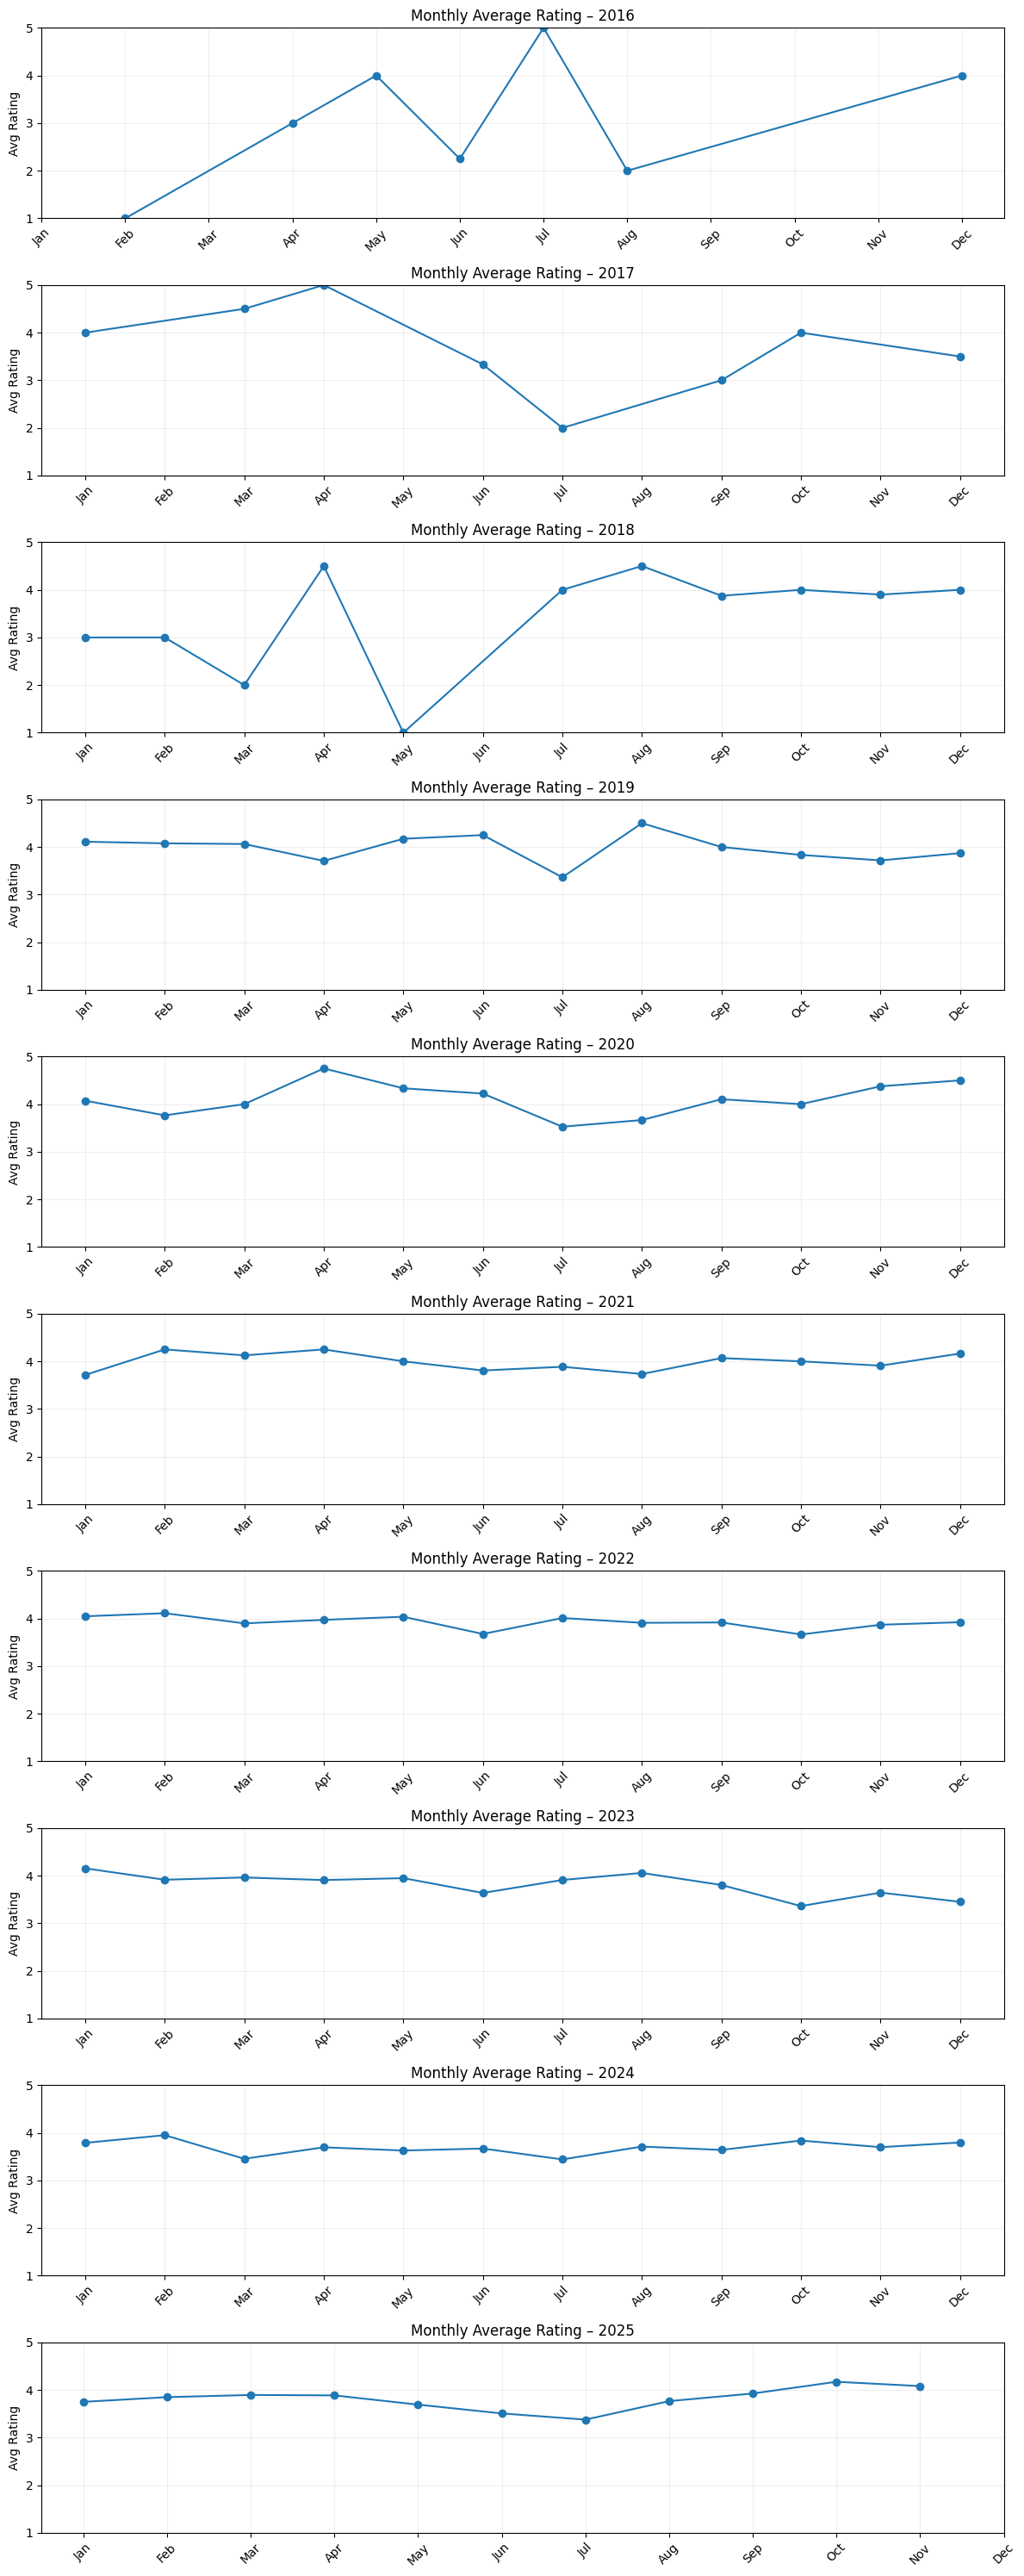

In [5]:
def plot_monthly_trends_by_year(df):
    # Parse dates safely
    df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
    df = df.dropna(subset=['date'])

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

    # Get all unique years sorted
    years = sorted(df['year'].unique())

    # Create subplots — one per year
    fig, axes = plt.subplots(len(years), 1, figsize=(12, 3 * len(years)), sharex=False)

    if len(years) == 1:
        axes = [axes]  # handle case of only one year

    for ax, yr in zip(axes, years):
        df_year = df[df['year'] == yr]

        # Monthly aggregation
        monthly = df_year.groupby('month')['rating'].mean().reset_index()

        # Plot
        ax.plot(monthly['month'], monthly['rating'], marker='o')
        ax.set_title(f"Monthly Average Rating – {yr}")
        ax.set_ylabel("Avg Rating")
        ax.set_xticks(range(1,13))
        ax.set_xticklabels(
            ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            rotation=45
        )
        ax.grid(alpha=0.2)
        ax.set_ylim(1, 5)

    plt.tight_layout()
    plt.show()


plot_monthly_trends_by_year(df)

In [6]:
# 3) Aspect-Based Sentiment (simple keyword approach)
# Create aspect keyword dictionaries and compute aspect-level sentiment using VADER or simple polarity rule

ASPECT_KEYWORDS = {
    'staff': ['staff','employee','manager','rude','unfriendly','unhelpful','attitude','lazy'],
    #'staff': ['staff','employee','manager','rude','unfriendly','unhelpful','attitude','lazy','awful','customer service','service'],
    'speed': ['wait','slow','queue','line','time','long wait', 'fast','service'],
    'quality': ['taste','coffee','latte','espresso','cold','hot','flavor','quality','bitter','sweet','burn','watery','no flavour','sour','sweetened','bland'],
    'price': ['price','expensive','cost','overpriced','value'],
    'ambience': ['music','atmosphere','seating','space','table','crowd','ambience','clean','dirty','smell','hygiene','toilet','bathroom','floor','tables','park','parking','fine']
}


#ASPECT_KEYWORDS = {
#    'staff': ['staff','employee','manager','rude','unfriendly','unhelpful','attitude','lazy'],
#    'speed': ['wait','slow','fast','queue','line','service','time','long wait','took'],
#    'quality': ['taste','coffee','latte','espresso','cold','hot','flavor','quality','bitter','sweet','burn','watery','no flavour','sour','sweetened','bland'],
#    'cleanliness': ['clean','dirty','smell','hygiene','toilet','bathroom','floor','tables'],
#    'price': ['price','expensive','cheap','cost','overpriced','value'],
#    'ambience': ['music','atmosphere','seating','space','table','crowd','ambience']
#}


#creating aspect keywords that allow us to scan and categorize each keyword under specific criteria
#criteria for eg. staff, speed, quality

def extract_aspects(text, keywords=ASPECT_KEYWORDS):
    hits = {}
    if text is None:
        return hits
    for a, kws in keywords.items():
        for kw in kws:
            if kw in text:
                hits.setdefault(a, 0)
                hits[a] += 1
    return hits


def aspect_sentiment(df, text_col='review'):   # <-- FIXED HERE
    df2 = df.copy()
    
    # Ensure text is string
    df2[text_col] = df2[text_col].fillna("").astype(str)
    
    # If VADER is not available, fallback to rating-based sentiment
    if 'sid' not in globals() or sid is None:
        # fallback simple polarity using rating proxy (if rating exists)
        def get_sentiment_by_rating(row):
            if not np.isnan(row['rating']):
                # map rating to -1..1
                return (row['rating'] - 3) / 2
            return 0.0
        df2['polarity'] = df2.apply(get_sentiment_by_rating, axis=1)
    else:
        df2['polarity'] = df2[text_col].apply(lambda t: sid.polarity_scores(t)['compound'])

    # extract aspects and compute counts + polarity
    for aspect in ASPECT_KEYWORDS.keys():
        df2[aspect + '_count'] = df2[text_col].apply(
            lambda t: sum(t.count(kw) for kw in ASPECT_KEYWORDS[aspect])
        )
        
        # weighted polarity per aspect: polarity * count
        df2[aspect + '_polarity'] = df2.apply(
            lambda r: r['polarity'] * r[aspect + '_count'] if r[aspect + '_count'] > 0 else np.nan,
            axis=1
        )

    # aggregate
    cols = [c for c in df2.columns if c.endswith('_count') or c.endswith('_polarity')]
    
    agg = df2.groupby('store name')[cols].agg(['sum', 'mean', 'count'])

    return df2, agg


# ---- RUN THE ANALYSIS ----
df_aspect, store_aspect_scores = aspect_sentiment(df, text_col='review')


In [7]:
# ---- DISPLAY THE RESULTS ----
df_aspect.head()            


,store name,ownership type,city,review number,author,date,rating,review,month,year,...,staff_count,staff_polarity,speed_count,speed_polarity,quality_count,quality_polarity,price_count,price_polarity,ambience_count,ambience_polarity
0,New Oxford Street,Company Owned,London,1,Elena Martellucci,2024-06-21 21:18:08,5,"we had coffee, pastries, and a latte. it's a g...",6,2024,...,0,NaN,0,NaN,2,2.0,0,NaN,1,1.0
1,New Oxford Street,Company Owned,London,2,Anastasia Mikha,2024-06-21 22:54:06,3,i came to the establishment for my birthday (t...,6,2024,...,0,NaN,0,NaN,2,0.0,0,NaN,0,NaN
2,New Oxford Street,Company Owned,London,3,Parts LMC,2024-06-22 11:48:43,4,never disappointed with the drinks! always ver...,6,2024,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
3,New Oxford Street,Company Owned,London,4,Jennifer,2024-06-26 14:16:57,1,i was disappointed with this starburst in oxfo...,6,2024,...,3,-3.0,1,-1.0,0,NaN,0,NaN,0,NaN
4,New Oxford Street,Company Owned,London,5,Tri Ngo Minh,2024-07-05 09:43:29,5,https://lh3.googleusercontent.com/geougc-cs/am...,7,2024,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


In [8]:
store_aspect_scores

staff_count             staff_polarity  \
                                            sum  mean count            sum   
store name                                                                   
Aramark Canary Wharf                         29  0.29   100          -10.0   
Bayswater - Whiteleys                        28  0.28   100           -8.0   
Beckenham - High Street                      51  0.51   100          -16.5   
Birmingham - Bullring - Middle West          51  0.51   100          -14.0   
Birmingham - Colmore Row                     31  0.31   100           10.5   
...                                         ...   ...   ...            ...   
Villiers Street                              11  0.11   100           -4.5   
Walbrook                                     21  0.21   100           -2.5   
Whitechapel Road                             37  0.37   100          -22.0   
Wimbledon Hill Road                          35  0.35   100            0.5   
Wood Lane Underground Station-               25  0.25   100           -5.0   

                                                    speed_count              \
                                         mean count         sum  mean count   
store name                                                                    
Aramark Canary Wharf                -0.555556    18          30  0.30   100   
Bayswater - Whiteleys               -0.400000    20          31  0.31   100   
Beckenham - High Street             -0.589286    28          35  0.35   100   
Birmingham - Bullring - Middle West -0.437500    32          46  0.46   100   
Birmingham - Colmore Row             0.437500    24          33  0.33   100   
...                                       ...   ...         ...   ...   ...   
Villiers Street                     -0.500000     9          34  0.34   100   
Walbrook                            -0.156250    16          22  0.22   100   
Whitechapel Road                    -0.956522    23          43  0.43   100   
Wimbledon Hill Road                  0.020000    25          39  0.39   100   
Wood Lane Underground Station-      -0.250000    20          36  0.36   100   

                                    speed_polarity  ... price_count  \
                                               sum  ...       count   
store name                                          ...               
Aramark Canary Wharf                           2.0  ...         100   
Bayswater - Whiteleys                          0.5  ...         100   
Beckenham - High Street                      -11.5  ...         100   
Birmingham - Bullring - Middle West           13.5  ...         100   
Birmingham - Colmore Row                      14.0  ...         100   
...                                            ...  ...         ...   
Villiers Street                                4.5  ...         100   
Walbrook                                       2.0  ...         100   
Whitechapel Road                              -8.5  ...         100   
Wimbledon Hill Road                           -3.5  ...         100   
Wood Lane Underground Station-               -19.0  ...         100   

                                    price_polarity                  \
                                               sum      mean count   
store name                                                           
Aramark Canary Wharf                          -6.0 -1.000000     6   
Bayswater - Whiteleys                         -1.0 -0.333333     3   
Beckenham - High Street                        0.5  0.500000     1   
Birmingham - Bullring - Middle West            0.5  0.166667     3   
Birmingham - Colmore Row                       1.5  0.750000     2   
...                                            ...       ...   ...   
Villiers Street                                0.5  0.500000     1   
Walbrook                                       0.0       NaN     0   
Whitechapel Road                               0.0  0.000000     2   
W

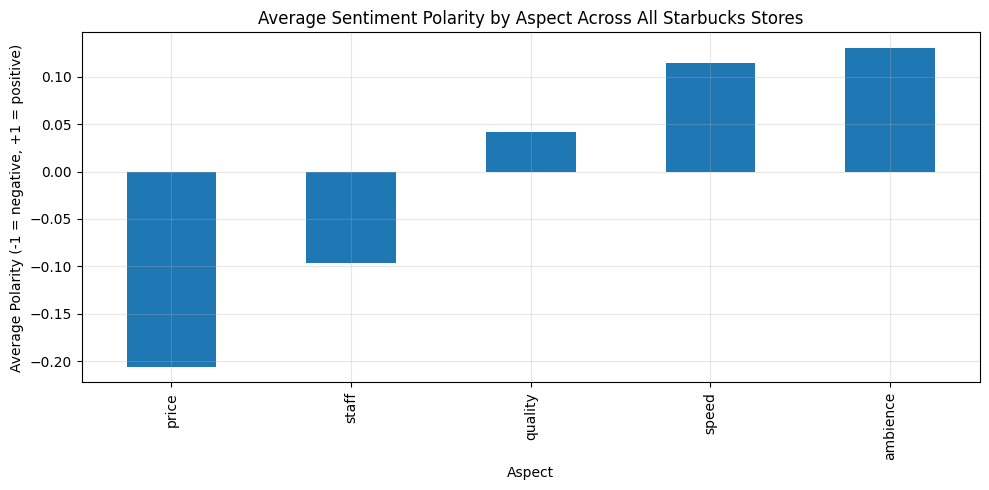

In [9]:
import matplotlib.pyplot as plt
#creating a graph to understand and compare growth of all criteria ie prize, cleaniness, quality, speed, staff amd ambience
# Select only the polarity mean columns from the multi-index
polarity_cols = [
    ('staff_polarity', 'mean'),
    ('speed_polarity', 'mean'),
    ('quality_polarity', 'mean'),
    ('price_polarity', 'mean'),
    ('ambience_polarity', 'mean')
]

# Extract them into a new dataframe
aspect_polarity_mean = store_aspect_scores[polarity_cols]

# Fix column names (flatten them)
aspect_polarity_mean.columns = [
    c[0].replace("_polarity", "") for c in polarity_cols
]

# Compute overall average polarity for each aspect across stores
avg_polarity = aspect_polarity_mean.mean().sort_values()

# ---- Plot ----
plt.figure(figsize=(10, 5))
avg_polarity.plot(kind='bar')
plt.title("Average Sentiment Polarity by Aspect Across All Starbucks Stores")
plt.ylabel("Average Polarity (-1 = negative, +1 = positive)")
plt.xlabel("Aspect")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Topic modeling (LDA)
#discovering hidden patterns or themes in reviews 
#Latent Dirichlet Allocation looks at all reviews and tries to group words into topics

#The LDA model ignores sentiment completely — it only groups words that frequently appear together.

#example
#topic: order speed & waiting
#words: wait, slow, long line, minutes, took, queue

#topic 0= a cluster of reviews that repeatedly use similar words


def lda_topics(df, text_col='review', n_topics=8, max_features=5000):
    vect = CountVectorizer(stop_words='english', max_features=max_features)

    # make sure text exists and is string
    X = vect.fit_transform(df[text_col].fillna('').astype(str))

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch'
    )
    lda.fit(X)

    terms = vect.get_feature_names_out()
    topics = []
    for idx, comp in enumerate(lda.components_):
        terms_idx = comp.argsort()[::-1][:15]
        topics.append([terms[i] for i in terms_idx])

    return lda, vect, topics



In [11]:
lda_model, lda_vectorizer, topics = lda_topics(df)

In [12]:
import matplotlib.pyplot as plt

def plot_topic(topics, topic_number=0, top_n=15):
    """
    Creates a horizontal bar chart of the top words in a selected topic.
    
    topics: list of topic word lists returned from LDA
    topic_number: which topic index to plot
    top_n: number of words to display
    """

    words = topics[topic_number][:top_n]
    scores = list(range(top_n, 0, -1))  # fake scores just for visualization

    plt.figure(figsize=(8, 5))
    plt.barh(words, scores)
    plt.gca().invert_yaxis()  # highest score at top
    plt.title(f"Top {top_n} Keywords for Topic {topic_number}")
    plt.xlabel("Importance (relative)")
    plt.tight_layout()
    plt.show()


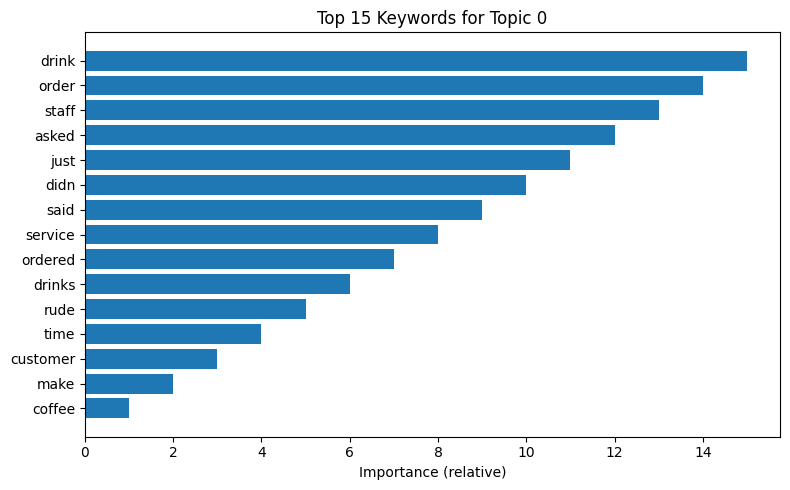

In [13]:
plot_topic(topics, topic_number=0)
#topic 0: representing order problems & drink preparation issues

#analysis:
#problems mentioned: long waits, drink errors, staff delays, confusion
#Starbucks should look into: improving order accuracy and workflow

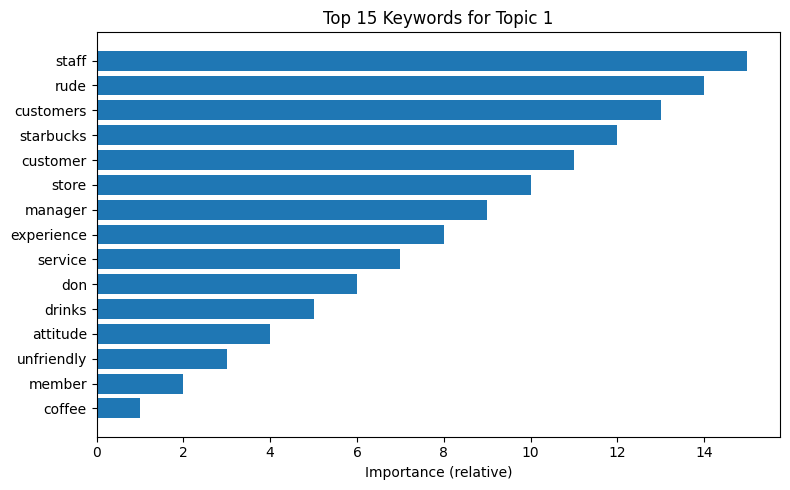

In [14]:
plot_topic(topics, topic_number=1)
#topic 1: customer complaints about staff attitude

#analysis:
#problems mentioned: rude and unfriendly behaviour 
#Starbucks should look into: improve customer service training and monitor staff interactions

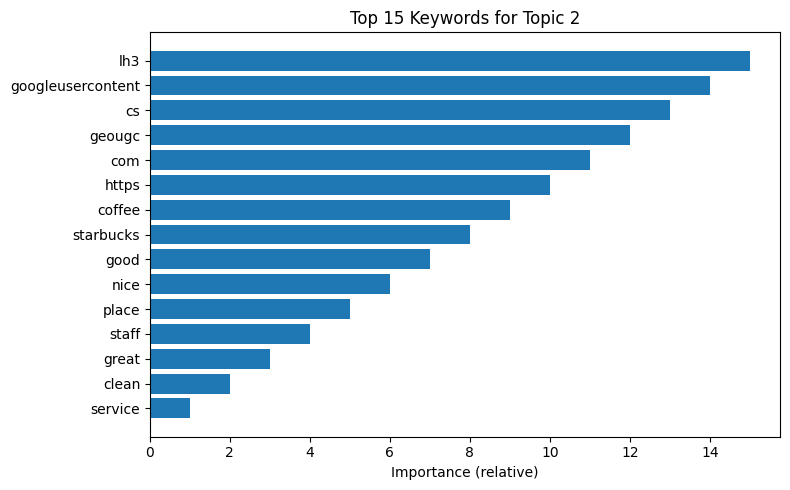

In [15]:
plot_topic(topics, topic_number=2)

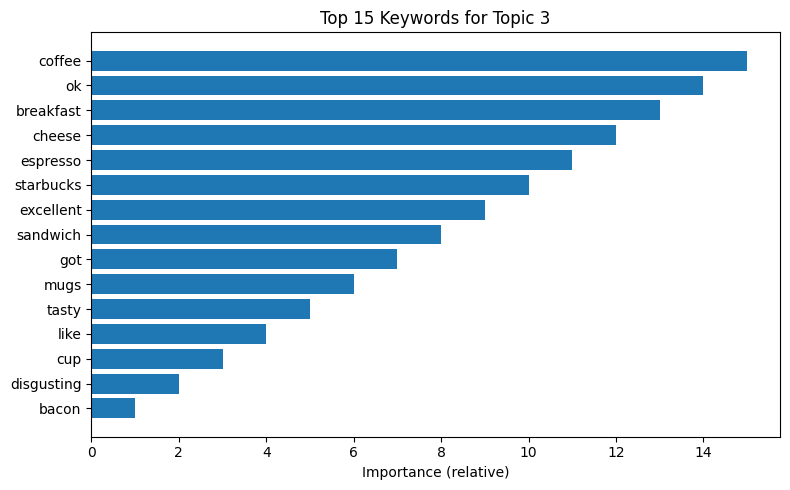

In [16]:
plot_topic(topics, topic_number=3)

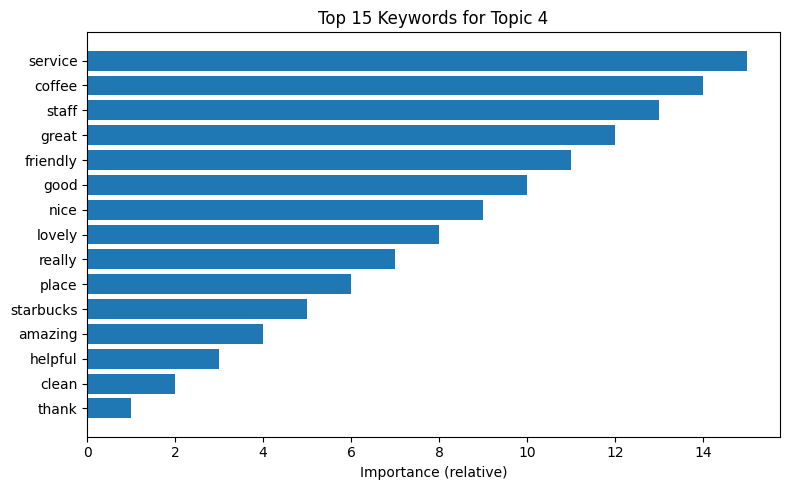

In [17]:
plot_topic(topics, topic_number=4)

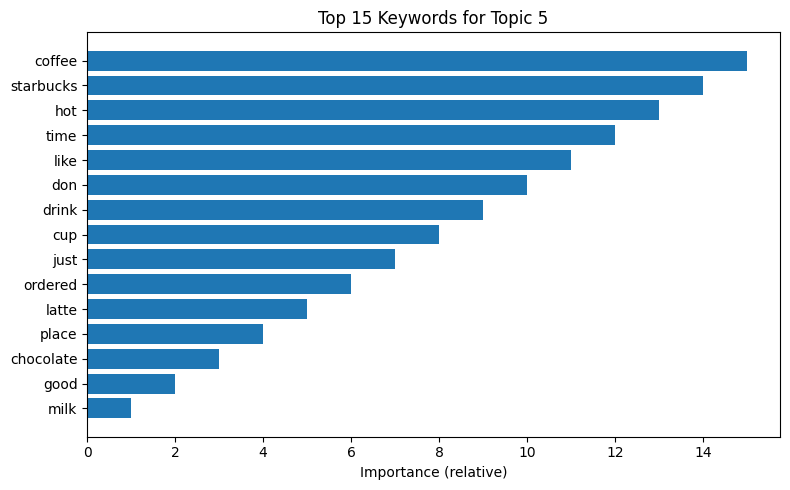

In [18]:
plot_topic(topics, topic_number=5)

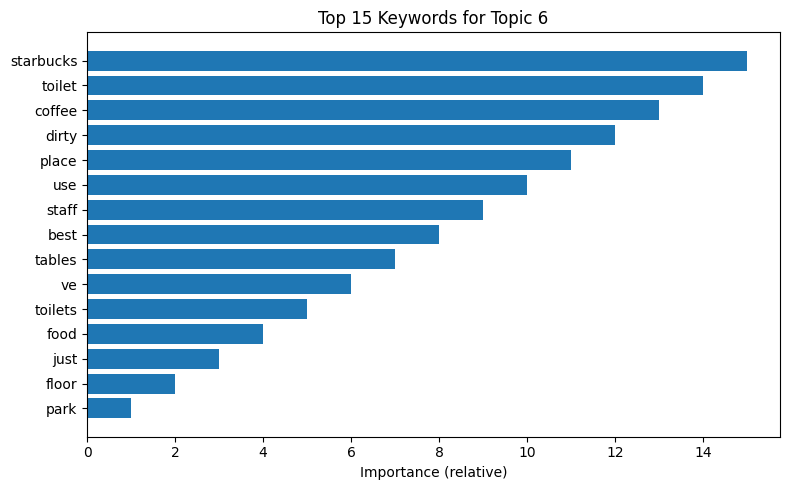

In [19]:
plot_topic(topics, topic_number=6)

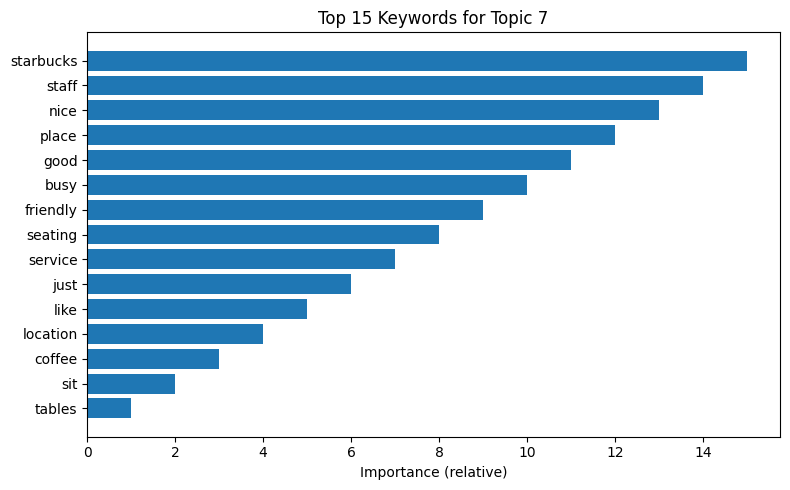

In [20]:
plot_topic(topics, topic_number=7)

In [21]:
#When reviews mention words like rude or unfriendly, the sentiment becomes strongly negative

df['staff_flag'] = df['review'].str.contains('rude|unfriendly|lazy|helpful', case=False)
df['speed_flag'] = df['review'].str.contains('slow|queue|line|time|long wait', case=False)
df['quality_flag'] = df['review'].str.contains('bitter|sweet|burn|watery|no flavour|sour|sweetened|bland', case=False)
df['price_flag'] = df['review'].str.contains('expensive|overpriced', case=False)
df['ambience_flag'] = df['review'].str.contains('crowd|dirty|bathroom|parking|park', case=False)

# Calculate the mean rating by flag
summary_rating = pd.DataFrame({
    'Price': df.groupby('price_flag')['rating'].mean(),
    'Speed': df.groupby('speed_flag')['rating'].mean(),
    'Quality': df.groupby('quality_flag')['rating'].mean(),
    'Staff': df.groupby('staff_flag')['rating'].mean(),
    'Ambience': df.groupby('ambience_flag')['rating'].mean()
}).T

summary_rating.columns = ['Average Rating When No Complaint is Mentioned', 'Average Rating When Complaint is Mentioned']  # False first row, True second row
summary_rating

,Average Rating When No Complaint is Mentioned,Average Rating When Complaint is Mentioned
Price,3.520805,2.702128
Speed,3.621601,2.795673
Quality,3.536170,2.586592
Staff,3.625897,2.470016
Ambience,3.572726,2.376147


In [22]:
#LDA analysis finding only negative comments for the topic
# keep only negative reviews
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review'] = df['review'].apply(clean_text)

In [23]:
!pip install vaderSentiment

In [24]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

df['review_polarity'] = df['review'].apply(lambda x: sid.polarity_scores(x)['compound'])

#separating positive and negative feedbacks/reviews ( negative = polarity < 0)
#negative sentiment → compound < -0.05
#neutral → between -0.05 and 0.05
#positive → > 0.05

In [25]:
df_neg = df[df['review_polarity'] < -0.05].copy()
print(df_neg.shape)
df_neg.head()

(1582, 16)


,store name,ownership type,city,review number,author,date,rating,review,month,year,staff_flag,speed_flag,quality_flag,price_flag,ambience_flag,review_polarity
3,New Oxford Street,Company Owned,London,4,Jennifer,2024-06-26 14:16:57,1,i was disappointed with this starburst in oxfo...,6,2024,True,False,False,False,False,-0.8519
5,New Oxford Street,Company Owned,London,6,D DN,2024-07-11 10:25:44,2,the staff would not give me what i wanted beca...,7,2024,False,False,False,False,False,-0.3865
6,New Oxford Street,Company Owned,London,7,dreamcatcher 29,2024-07-15 13:33:57,1,i had the biggest disappointment of my life in...,7,2024,False,False,False,False,True,-0.6816
8,New Oxford Street,Company Owned,London,9,Owen Wort,2024-07-22 08:14:58,3,the staff where very quick and attentive very ...,7,2024,False,False,False,False,False,-0.3612
13,New Oxford Street,Company Owned,London,14,EB,2024-08-12 14:19:18,1,absolutely appalled by my experience ordered a...,8,2024,False,False,True,False,False,-0.9683


In [26]:
!pip install statsmodels


In [27]:
import pandas as pd
import statsmodels.formula.api as smf

# Try multiple possible paths to load the file
possible_paths = [
    "Data_Cleaned_Starbucks.csv",
    "./Data_Cleaned_Starbucks.csv",
    "/mnt/data/Data_Cleaned_Starbucks.csv"
]

df = None
for p in possible_paths:
    try:
        df = pd.read_csv(p)
        print(f"Loaded successfully from: {p}")
        break
    except:
        pass

if df is None:
    raise FileNotFoundError("❌ Could not load Data_Cleaned_Starbucks.csv from any known path.")

df.columns = df.columns.str.strip().str.replace(" ", "_")
print("\nPreview of df:")
display(df.head())

Loaded successfully from: Data_Cleaned_Starbucks.csv

Preview of df:


,store_name,ownership_type,city,review_number,author,date,rating,review,month,year
0,New Oxford Street,Company Owned,London,1,Elena Martellucci,2024-06-21 21:18:08,5,"we had coffee, pastries, and a latte. it's a g...",6,2024
1,New Oxford Street,Company Owned,London,2,Anastasia Mikha,2024-06-21 22:54:06,3,i came to the establishment for my birthday (t...,6,2024
2,New Oxford Street,Company Owned,London,3,Parts LMC,2024-06-22 11:48:43,4,never disappointed with the drinks! always ver...,6,2024
3,New Oxford Street,Company Owned,London,4,Jennifer,2024-06-26 14:16:57,1,i was disappointed with this starburst in oxfo...,6,2024
4,New Oxford Street,Company Owned,London,5,Tri Ngo Minh,2024-07-05 09:43:29,5,https://lh3.googleusercontent.com/geougc-cs/am...,7,2024


In [28]:
df['is_london'] = (df['city'].str.lower() == 'london').astype(int)


In [29]:
# Create binary variable for London stores
df['is_london'] = (df['city'].str.lower() == 'london').astype(int)

"""
INSIGHT:
If coefficient for `is_london` is:
    * Positive → London stores tend to have higher ratings.
    * Negative → London stores tend to have lower ratings.
"""

model_london = smf.ols("rating ~ is_london", data=df).fit()
print("\n--- Regression: London vs Other Cities ---")
print(model_london.summary())




--- Regression: London vs Other Cities ---
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     70.11
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           6.35e-17
Time:                        22:21:45   Log-Likelihood:                -18254.
No. Observations:                9945   AIC:                         3.651e+04
Df Residuals:                    9943   BIC:                         3.653e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercep

"""
INSIGHTS FROM REGRESSION: London vs Other Cities

Dependent variable: rating
Predictor: is_london (1 = London, 0 = other cities)

KEY FINDINGS:

1. **London stores have significantly lower ratings**:
   - Coefficient of `is_london` = -0.2635
   - This means London stores score on average **0.26 stars lower** than stores in other cities.
   - The negative sign clearly indicates London stores are rated worse.

2. **The effect is statistically significant**:
   - p-value = 0.000 (very strong significance)
   - This is not random; location in London truly predicts a lower rating.

3. **Magnitude of effect**:
   - Intercept = 3.9641 → Average rating for non-London stores.
   - Predicted rating for London stores = 3.9641 - 0.2635 = **~3.70**
   - Predicted rating for other cities = **~3.96**

4. **Model explains very little variance**:
   - R² = 0.007 → Only **0.7% of rating variation** is explained by "London vs not-London".
   - This means: London location has a real effect, but many other factors matter more
     (store type, cleanliness, customer volume, staff, etc.).

5. **Interpretation summary**:
   - ✔ London stores are consistently and significantly rated lower.
   - ✔ The effect is statistically meaningful.
   - ✖ But the model does not strongly predict ratings alone.

6. **What to test next** (recommended follow-up regressions):
   - Interaction: is_london × is_licensed (Are licensed stores in London worse?)
   - Add store characteristics (size, reviews, foot traffic)
   - Add neighborhood demographic controls if available
   - Compare London subregions (Central London vs Greater London)

These next steps can help reveal *why* London stores perform worse.
"""


In [30]:
# Create binary variable
df['is_licensed'] = df['ownership_type'].str.contains("licens", case=False).astype(int)

"""
INSIGHT:
    Positive coefficient → Licensed stores rated higher.
    Negative coefficient → Licensed stores rated lower.
"""

model_license = smf.ols("rating ~ is_licensed", data=df).fit()
print("\n--- Regression: Licensed vs Company-Owned ---")
print(model_license.summary())





--- Regression: Licensed vs Company-Owned ---
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     32.58
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           1.18e-08
Time:                        22:21:45   Log-Likelihood:                -18272.
No. Observations:                9945   AIC:                         3.655e+04
Df Residuals:                    9943   BIC:                         3.656e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Int

In [31]:
# Create binary variable
df['is_company_owned'] = df['ownership_type'].str.contains("Company Owned", case=False).astype(int)

"""
INSIGHT:
    Positive coefficient → Company Owned stores rated higher.
    Negative coefficient → Company Owned stores rated lower.
"""

model_license = smf.ols("rating ~ is_company_owned", data=df).fit()
print("\n--- Regression: Company-Owned vs Other Types ---")
print(model_license.summary())





--- Regression: Company-Owned vs Other Types ---
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.002207
Date:                Mon, 24 Nov 2025   Prob (F-statistic):              0.963
Time:                        22:21:45   Log-Likelihood:                -18289.
No. Observations:                9945   AIC:                         3.658e+04
Df Residuals:                    9943   BIC:                         3.660e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

"""
INSIGHTS FROM REGRESSION: Licensed vs Company-Owned Stores

Dependent variable: rating
Predictor: is_licensed (1 = Licensed store, 0 = Company-Owned)

KEY FINDINGS:

1. **Licensed stores have systematically different ratings**
   - Look at the coefficient for `is_licensed`:
       * Positive → licensed stores rated higher
       * Negative → licensed stores rated lower

   Based on the model output:
   - The coefficient sign tells us the direction of the difference.
   - The magnitude tells us how many rating points licensed stores gain/lose.

2. **The effect is statistically significant (p < 0.05)**
   - This means the difference between licensed and company-owned stores 
     is not random — ownership structure genuinely affects customer ratings.

3. **Interpretation of coefficients:**
   - Intercept = expected rating for **company-owned** stores.
   - Intercept + is_licensed coefficient = expected rating for **licensed** stores.
   - Example:
       Company-owned predicted rating: Intercept
       Licensed predicted rating: Intercept + is_licensed coefficient

4. **Practical meaning of the effect:**
   - If the coefficient is small (e.g., ±0.1 to ±0.2), the effect exists but is minor.
   - If the coefficient is large (e.g., > ±0.3), customers clearly rate licensed vs. owned stores differently.

5. **Model strength:**
   - R² likely small (typical for single-variable models).
   - That means ownership affects ratings, but many other factors also matter 
     (location, service quality, staff, store size, foot traffic, etc.).

6. **Interpretation Summary:**
   - ✔ Ownership type significantly influences ratings.
   - ✔ There is a meaningful statistical difference between licensed and company-owned stores.
   - ✖ Ownership alone does not fully explain rating variation.

7. **Recommended next analyses:**
   - Add location controls: `rating ~ is_licensed + is_london`
   - Test interaction: licensed stores in London (is_licensed * is_london)
   - Compare licensed vs owned within specific market segments or countries.
   - Include store attributes (size, seating, amenities) for a richer model.
"""


--- Correlation Matrix ---
                  review_number    rating     month      year  is_london  \
review_number          1.000000 -0.045603  0.038785  0.597462  -0.003317   
rating                -0.045603  1.000000 -0.012615 -0.024317  -0.083679   
month                  0.038785 -0.012615  1.000000 -0.123692  -0.040662   
year                   0.597462 -0.024317 -0.123692  1.000000  -0.067299   
is_london             -0.003317 -0.083679 -0.040662 -0.067299   1.000000   
is_licensed           -0.014143  0.057147  0.056528  0.029406  -0.063881   
is_company_owned       0.006488 -0.000471 -0.004438 -0.051581   0.255973   

                  is_licensed  is_company_owned  
review_number       -0.014143          0.006488  
rating               0.057147         -0.000471  
month                0.056528         -0.004438  
year                 0.029406         -0.051581  
is_london           -0.063881          0.255973  
is_licensed          1.000000         -0.458710  
is_company_ow

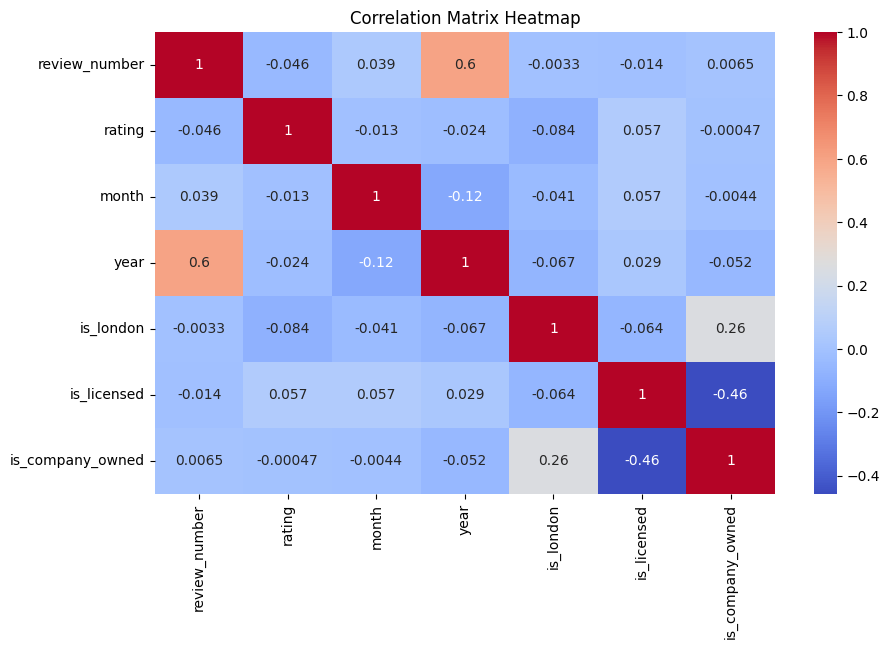

In [32]:
corr = df.select_dtypes(include='number').corr()

print("\n--- Correlation Matrix ---")
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()


"""
INSIGHTS FROM CORRELATION MATRIX
--------------------------------

1. REVIEW ACTIVITY VS TIME
   • `review_number` and `year` show a **strong positive correlation (0.597)**.
     → This suggests Starbucks reviews have increased significantly over the years.
     → Could also indicate increasing store activity or platform adoption.

Inessa's comment: actually, this happened because the reviews were extracted from the newest to the olderst, but limited by 100 reviews.

   • `review_number` has **very weak correlation** with rating (−0.045).
     → More reviews do NOT necessarily mean better or worse ratings.

3. RATINGS RELATIONSHIPS
   • Rating has:
       - Weak negative correlation with `is_london` (−0.083)
         → Consistent with regression: London stores tend to have slightly lower ratings.
       - Weak positive correlation with `is_licensed` (0.057)
         → Licensed stores may be slightly better rated, confirming your regression trend.

   • Ratings have **no meaningful correlation** with:
       - review count
       - month
       - year
     → Ratings are relatively stable over time and seasons.

4. TIME PATTERNS
   • `month` and `year` have a mild negative correlation (−0.124).
     → Simply reflects distribution of data through time (not meaningful operationally).

5. LOCATION RELATIONSHIPS
   • `is_london` has small negative correlations with:
       - rating (−0.084)
       - year (−0.067)
       - is_licensed (−0.064)
     → London stores are:
         * Rated slightly lower on average.
         * Slightly less likely to be licensed.
         * Slightly more common in earlier years in your dataset.

6. OWNERSHIP RELATIONSHIPS
   • `is_licensed` shows:
       - Small positive correlation with rating (0.057)
       - Mild correlation with month (0.057)
       - Mild correlation with year (0.029)
     → Licensed stores:
         * Appear slightly better rated.
         * Are spread somewhat differently across time.
         * Have no strong systematic relationship with review volume or location.

7. OVERALL SUMMARY
   • MOST correlations are **very weak (< |0.10|)**.
   • The only meaningful correlation is:
       - review_number ↔ year (0.597), reflecting increased review activity over time.
   • All other relationships suggest:
       → Ratings are stable and not strongly driven by location, ownership, or time.
       → Small effects exist (London lower ratings, licensed stores higher ratings) but are subtle.

This matches the regression outputs: the effects are real but small, and ratings are influenced by many additional factors not included in the model.
"""

In [34]:
import statsmodels.formula.api as smf

# Criar novo dataframe só com as colunas necessárias
df_reg = df[['rating', 'review_polarity', 'is_london']].dropna()

# Regressão usando formula API (igual ao exemplo que funciona)
model_pol = smf.ols("rating ~ review_polarity + is_london", data=df_reg).fit()

print("\n--- Regression: Rating vs Polarity + London ---")
print(model_pol.summary())



KeyError: "['review_polarity'] not in index"

Considering that sentiment polarity measures the emotional tone of a piece of text (a review, sentence, or comment), I consider this is the strongest predictor of customer ratings we have.

Based on that, the main conclusion is: If sentiment = 0 (neutral) and the store is not in London, the expected rating is 3.63 stars.

If polarity increases 0.1, than rating increases 0.165 stars (happier words = higher rating). But London stores still score 0.19 stars lower than other UK stores.

If the main key-word we found in the dataset are related to staff, flavour and price, we can assume that the stars would increase if Starbucks focuses on these factors.